# 🎯 Robust Regression Engine

## 🧹 Part B: Dataset Understanding & Preparation

### You are provided with a real estate dataset containing:

* Property size and structural attributes
* Location-based numerical indicators
* Property age and renovation details
* Target variable: House Price

In [40]:
import pandas as pd

df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

In [41]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [42]:
df.tail()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
3795,203796,2010-04-01,992,3,3,7.4,22,11.6,0,0,3.45,10901127
3796,203797,2019-04-01,2295,4,4,2.8,22,23.0,0,0,5.38,20662246
3797,203798,2020-10-01,2050,2,1,8.7,38,11.0,0,0,2.90,32486165
3798,203799,2012-03-01,1957,6,4,7.8,22,1.2,0,0,4.31,25004531
3799,203800,2013-01-01,1846,4,3,6.7,23,1.0,1,0,7.02,24138565


In [43]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [45]:
df.shape

(3800, 12)

### 6. Identify features and target variable. 

In [46]:
# Features
X = df.drop("house_price_inr", axis=1)

# Target variable
y = df["house_price_inr"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index'],
      dtype='object')

Target:
house_price_inr


#### 💡 Insights: Features & Target
- The target is `house_price_inr`; every other column is a candidate feature.
- `property_id` carries no predictive meaning and `sale_date` is not numeric, so they need to be dropped or encoded before modelling (handled in Q8).
- This is a continuous target, so this is a **regression** problem.

### 7. Perform a train-test split.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3040, 11)
X_test: (760, 11)
y_train: (3040,)
y_test: (760,)


#### 💡 Insights: Train-Test Split
- An **80/20 split** gives 3,040 training and 760 test rows, enough data to learn from and still evaluate reliably.
- `random_state=42` makes the split reproducible, so all later models are compared on the same test set.
- Features and target shapes match (3,040 / 760), so there is no alignment issue.

### 8. Apply basic preprocessing (scaling where required).

In [48]:
from sklearn.preprocessing import StandardScaler
X = df[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "property_age",
        "distance_city_km",
        "near_school",
        "near_metro",
        "crime_rate_index"
    ]
]

y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 💡 Insights: Preprocessing & Scaling
- Only the 9 numeric predictors are kept; `property_id` and `sale_date` are removed.
- `StandardScaler` is **fit on training data only** and then applied to the test data, which prevents data leakage.
- Scaling matters for Ridge, Lasso and SVR because features range from 0/1 flags to thousands of sq ft. Tree models do not need it.

## 📈 Part C: Regularized Linear Models

### 9. Implement Ridge Regression (L2).

In [49]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
ridge_test_error = mean_squared_error(y_test, ridge_test_pred)

print("Ridge Training Error:", ridge_train_error)
print("Ridge Validation Error:", ridge_test_error)

Ridge Training Error: 6253047097253.315
Ridge Validation Error: 6545419443619.511


#### 💡 Insights: Ridge Regression
- Training MSE (≈ 6.25×10¹²) and validation MSE (≈ 6.55×10¹²) are very close, so the model **generalises well** with no overfitting.
- The small gap means the data is largely linear and a simple model already captures most of the pattern.
- MSE is in squared rupees, so it looks huge; RMSE (≈ ₹25.6 lakh) is easier to interpret.

### 10. Implement Lasso Regression (L1).

In [50]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_error = mean_squared_error(y_train, lasso_train_pred)
lasso_test_error = mean_squared_error(y_test, lasso_test_pred)

print("Lasso Training Error:", lasso_train_error)
print("Lasso Validation Error:", lasso_test_error)

Lasso Training Error: 6253028346903.975
Lasso Validation Error: 6543996619352.281


#### 💡 Insights: Lasso Regression
- Lasso gives almost the same errors as Ridge (validation MSE ≈ 6.54×10¹²), again with a tiny train-validation gap.
- At α = 1 no feature is fully removed, because all 9 predictors are informative to some degree.
- L1 and L2 regularization make little difference here because the data has low noise and little multicollinearity.

### 11. Tune the regularization parameter (α) using cross-validation.

In [51]:
from sklearn.model_selection import GridSearchCV

alphas = [0.01, 0.1, 1, 10, 100]

# Ridge
ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])


# Lasso
lasso_grid = GridSearchCV(
    Lasso(),
    {"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])

Best Ridge Alpha: 1
Best Lasso Alpha: 100


#### 💡 Insights: Tuning α with Cross-Validation
- Best α: **Ridge = 1**, **Lasso = 100**. Ridge prefers mild shrinkage, while Lasso preferred the strongest value in the grid.
- Lasso's best α sits at the **edge of the grid**, so a wider range (e.g. 1000+) could be tested to confirm it is really optimal.
- Since scores barely change across α, the model is not very sensitive to the regularization strength.

### 12. Compare Ridge and Lasso based on:
* Training error
* Validation error
* Feature coefficient behavior

In [52]:
# Best models
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

# Predictions
ridge_train_pred = best_ridge.predict(X_train_scaled)
ridge_test_pred = best_ridge.predict(X_test_scaled)

lasso_train_pred = best_lasso.predict(X_train_scaled)
lasso_test_pred = best_lasso.predict(X_test_scaled)

# Errors
ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
ridge_test_error = mean_squared_error(y_test, ridge_test_pred)

lasso_train_error = mean_squared_error(y_train, lasso_train_pred)
lasso_test_error = mean_squared_error(y_test, lasso_test_pred)

print("Ridge Training Error:", ridge_train_error)
print("Ridge Validation Error:", ridge_test_error)

print("\nLasso Training Error:", lasso_train_error)
print("Lasso Validation Error:", lasso_test_error)

Ridge Training Error: 6253047097253.315
Ridge Validation Error: 6545419443619.511

Lasso Training Error: 6253028410486.958
Lasso Validation Error: 6544107497269.08


In [53]:
comparison = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": best_ridge.coef_,
    "Lasso Coefficient": best_lasso.coef_
})

print(comparison)

            Feature  Ridge Coefficient  Lasso Coefficient
0         area_sqft       6.937545e+06       6.944831e+06
1          bedrooms       2.973655e+05       2.911937e+05
2         bathrooms       2.853268e+05       2.853815e+05
3    location_score       3.676865e+06       3.678911e+06
4      property_age      -6.513024e+05      -6.513909e+05
5  distance_city_km      -3.016962e+04      -2.873756e+04
6       near_school       1.697147e+04       1.680345e+04
7        near_metro       5.820432e+04       5.819679e+04
8  crime_rate_index      -1.354728e+05      -1.353088e+05


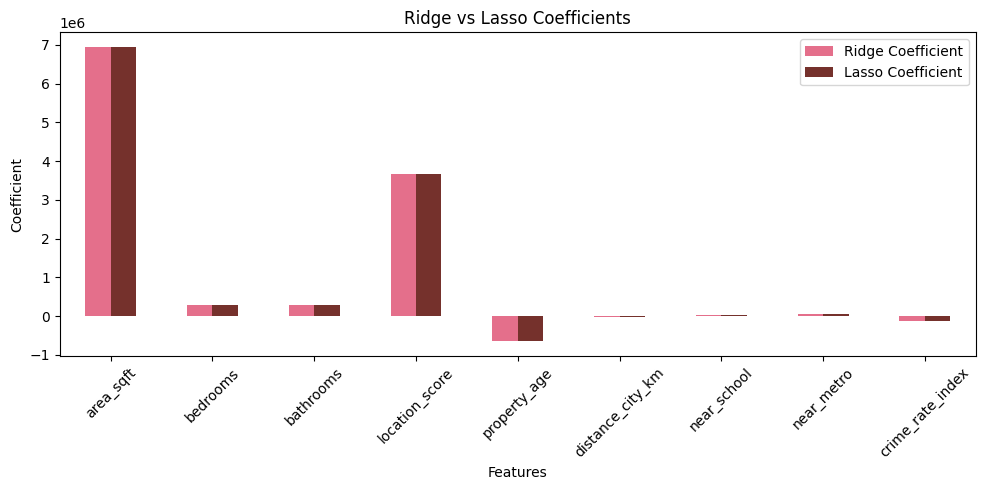

In [54]:
import matplotlib.pyplot as plt

comparison.set_index("Feature")[["Ridge Coefficient", "Lasso Coefficient"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#E46F8B", "#75312C"]
)

plt.title("Ridge vs Lasso Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 💡 Insights: Ridge vs Lasso Comparison
- **Errors:** Training and validation errors are nearly identical for both models (Lasso is marginally better on validation).
- **Coefficients:** Both models agree closely. `area_sqft` (≈ +6.9M) and `location_score` (≈ +3.7M) are the strongest price drivers, followed by `property_age` (negative, ≈ −0.65M).
- **Behaviour:** Lasso slightly shrinks weak features like `distance_city_km`, `near_school` and `bedrooms`, but does not zero any. Ridge and Lasso are practically equivalent here.

## 📘 Part D: Cross-Validation Strategie

### 13. Apply and compare the following cross-validation techniques:

### K-Fold Cross-Validation

In [55]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

kfold_mse = -kfold_scores

print("K-Fold MSE:", kfold_mse)
print("K-Fold Average MSE:", kfold_mse.mean())

K-Fold MSE: [6.31590619e+12 7.13460433e+12 6.08739446e+12 5.83257859e+12
 6.20905382e+12]
K-Fold Average MSE: 6315907476856.197


#### 💡 Insights: K-Fold CV
- Fold MSEs range from ≈ 5.83×10¹² to 7.13×10¹², with an average of **≈ 6.32×10¹²**.
- The moderate fold-to-fold spread shows some variation depending on which rows land in validation.
- The CV average is close to the training error seen earlier, confirming the model is stable.

### Stratified K-Fold Cross-Validation (by binning target values)

In [56]:
from sklearn.model_selection import StratifiedKFold

# Divide target into 5 bins
y_bins = pd.qcut(y_train, q=5, labels=False)

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_index, test_index in stratified_kfold.split(X_train_scaled, y_bins):
    
    X_train_cv = X_train_scaled[train_index]
    X_test_cv = X_train_scaled[test_index]
    
    y_train_cv = y_train.iloc[train_index]
    y_test_cv = y_train.iloc[test_index]
    
    model.fit(X_train_cv, y_train_cv)
    
    prediction = model.predict(X_test_cv)
    
    mse = mean_squared_error(y_test_cv, prediction)
    stratified_scores.append(mse)

print("Stratified K-Fold MSE:", stratified_scores)
print("Stratified K-Fold Average MSE:", sum(stratified_scores) / len(stratified_scores))

Stratified K-Fold MSE: [6546195656680.306, 6048989983626.258, 5967935004661.406, 5971654985564.865, 6963750835876.492]
Stratified K-Fold Average MSE: 6299705293281.865


#### 💡 Insights: Stratified K-Fold CV
- Binning the target into 5 quantiles keeps each fold's price distribution similar, giving an average MSE of **≈ 6.30×10¹²**.
- Fold scores still vary (5.97×10¹² to 6.96×10¹²), so stratification does not remove all randomness.
- The result is very close to plain K-Fold because the price distribution is already fairly balanced.

### Leave-One-Out Cross-Validation

In [57]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

loo_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=loo,
    scoring="neg_mean_squared_error"
)

loo_mse = -loo_scores

print("LOOCV Average MSE:", loo_mse.mean())

LOOCV Average MSE: 6298363401570.2


#### 💡 Insights: Leave-One-Out CV
- LOOCV gives an average MSE of **≈ 6.30×10¹²**, virtually the same as K-Fold.
- It is the least biased estimate since each model trains on nearly all data, but it is computationally expensive (one fit per row).
- For a dataset of this size, 5-fold CV gives the same conclusion at a fraction of the cost.

### Time Series Split (using a time-related feature)

In [58]:
from sklearn.model_selection import TimeSeriesSplit

# Sort data according to date
df_time = df.sort_values("sale_date")

X_time = df_time[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "property_age",
        "distance_city_km",
        "near_school",
        "near_metro",
        "crime_rate_index"
    ]
]

y_time = df_time["house_price_inr"]

# Scale the data
X_time_scaled = scaler.fit_transform(X_time)

time_split = TimeSeriesSplit(n_splits=5)

time_scores = cross_val_score(
    model,
    X_time_scaled,
    y_time,
    cv=time_split,
    scoring="neg_mean_squared_error"
)

time_mse = -time_scores

print("Time Series MSE:", time_mse)
print("Time Series Average MSE:", time_mse.mean())

Time Series MSE: [6.93104908e+12 6.08525180e+12 6.01807233e+12 6.05795363e+12
 6.80041024e+12]
Time Series Average MSE: 6378547416733.665


#### 💡 Insights: Time Series Split
- Average MSE is **≈ 6.38×10¹²**, the highest of the four strategies, since it always trains on the past and validates on the future.
- Fold errors (≈ 6.0×10¹² to 6.9×10¹²) show some drift over time, which suggests prices may shift slightly across periods.
- This is the most realistic strategy if the model will predict future sales, as it avoids using future data to predict the past.

### 14. Analyze how performance metrics vary across different CV strategies.

In [59]:
cv_results = pd.DataFrame({
    "CV Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "Leave-One-Out",
        "Time Series Split"
    ],
    "Average MSE": [
        kfold_mse.mean(),
        sum(stratified_scores) / len(stratified_scores),
        loo_mse.mean(),
        time_mse.mean()
    ]
})

print(cv_results)

         CV Strategy   Average MSE
0             K-Fold  6.315907e+12
1  Stratified K-Fold  6.299705e+12
2      Leave-One-Out  6.298363e+12
3  Time Series Split  6.378547e+12


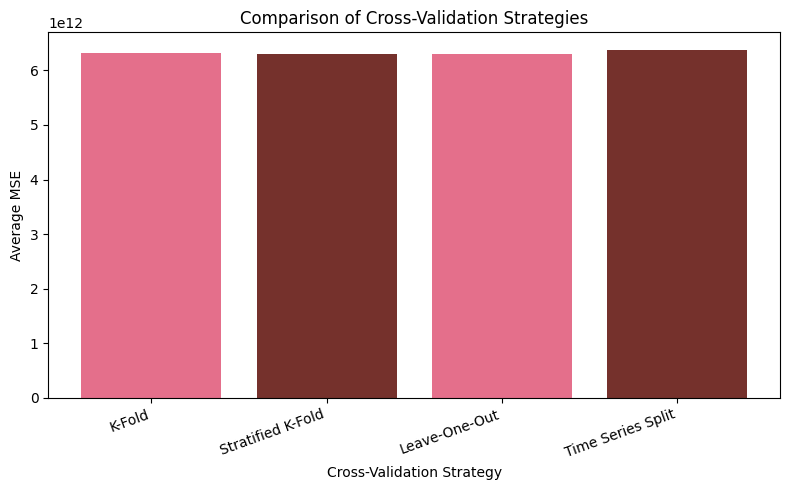

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["CV Strategy"],
    cv_results["Average MSE"],
    color=["#E46F8B", "#75312C", "#E46F8B", "#75312C"]
)

plt.xlabel("Cross-Validation Strategy")
plt.ylabel("Average MSE")
plt.title("Comparison of Cross-Validation Strategies")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

#### 💡 Insights: CV Strategy Comparison
- All four strategies land within about **1.3%** of each other (6.30×10¹² to 6.38×10¹²), so the model's performance estimate is **robust**.
- K-Fold, Stratified and LOOCV are nearly identical; Time Series Split is slightly higher because of its stricter, order-based validation.
- Practical takeaway: use K-Fold for speed, and Time Series Split when temporal order matters.

### 🌳 Part E: Tree-Based Regression Models

### 15. Implement Decision Tree Regression.

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

tree_train_mse = mean_squared_error(y_train, tree_train_pred)
tree_test_mse = mean_squared_error(y_test, tree_test_pred)

tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

print("Decision Tree Training MSE:", tree_train_mse)
print("Decision Tree Validation MSE:", tree_test_mse)

print("Decision Tree Training R2:", tree_train_r2)
print("Decision Tree Validation R2:", tree_test_r2)

Decision Tree Training MSE: 0.0
Decision Tree Validation MSE: 11418620582615.756
Decision Tree Training R2: 1.0
Decision Tree Validation R2: 0.8582157251362128


#### 💡 Insights: Decision Tree (Unconstrained)
- Training R² of **1.0** with training MSE of **0** means the tree memorised the training data.
- Validation R² drops to ≈ **0.858**, and validation MSE (≈ 1.14×10¹³) is much worse than the regularized linear models. This is classic **overfitting**.
- An unrestricted tree grows until every leaf is pure, so it needs complexity control.

### 16. Control tree complexity using hyperparameters (max depth, min samples).

In [24]:
tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

tree_train_mse = mean_squared_error(y_train, tree_train_pred)
tree_test_mse = mean_squared_error(y_test, tree_test_pred)

print("Training MSE:", tree_train_mse)
print("Validation MSE:", tree_test_mse)

Training MSE: 7503005055146.253
Validation MSE: 9385836459040.166


#### 💡 Insights: Controlling Tree Complexity
- Limiting depth (5) and leaf sizes reduces validation MSE from ≈ 1.14×10¹³ to **≈ 9.39×10¹²**, about an **18% improvement**.
- Training error rises (from 0 to ≈ 7.5×10¹²), which is expected: the model trades memorisation for generalisation.
- The train-validation gap is now moderate, so the tree is much more reliable, though still behind Ridge.

### 17. Implement Random Forest Regression.

In [25]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

forest.fit(X_train, y_train)

forest_train_pred = forest.predict(X_train)
forest_test_pred = forest.predict(X_test)

forest_train_mse = mean_squared_error(y_train, forest_train_pred)
forest_test_mse = mean_squared_error(y_test, forest_test_pred)

forest_train_r2 = r2_score(y_train, forest_train_pred)
forest_test_r2 = r2_score(y_test, forest_test_pred)

print("Random Forest Training MSE:", forest_train_mse)
print("Random Forest Validation MSE:", forest_test_mse)

print("Random Forest Training R2:", forest_train_r2)
print("Random Forest Validation R2:", forest_test_r2)

Random Forest Training MSE: 5505101254770.176
Random Forest Validation MSE: 6904658266616.438
Random Forest Training R2: 0.92621072099327
Random Forest Validation R2: 0.9142653039015152


#### 💡 Insights: Random Forest
- Training R² ≈ **0.926** and validation R² ≈ **0.914** show strong performance with only a small gap.
- Averaging 100 trees reduces variance, so the forest generalises far better than a single tree.
- Validation MSE (≈ 6.90×10¹²) is close to the linear models, which suggests the underlying relationship is mostly linear.

### 18. Compare single-tree vs ensemble performance.

In [66]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training MSE": [
        tree_train_mse,
        forest_train_mse
    ],
    "Validation MSE": [
        tree_test_mse,
        forest_test_mse
    ],
    "Training R2": [
        tree_train_r2,
        forest_train_r2
    ],
    "Validation R2": [
        tree_test_r2,
        forest_test_r2
    ]
})

print(comparison)

           Model  Training MSE  Validation MSE  Training R2  Validation R2
0  Decision Tree  7.503005e+12    9.385836e+12     0.899431       0.883457
1  Random Forest  5.505101e+12    6.904658e+12     0.926211       0.914265


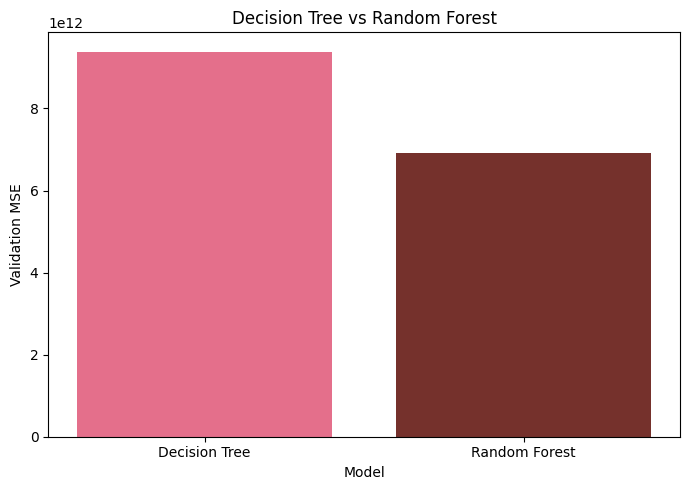

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation MSE"],
    color=["#E46F8B", "#75312C"]
)

plt.xlabel("Model")
plt.ylabel("Validation MSE")
plt.title("Decision Tree vs Random Forest")
plt.tight_layout()
plt.show()

#### 💡 Insights: Single Tree vs Ensemble
- Random Forest beats the Decision Tree on both errors: validation MSE ≈ **6.90×10¹²** vs 9.39×10¹² (about **26% lower**), and validation R² ≈ 0.914 vs 0.883.
- The forest's training and validation scores are closer together, showing better stability.
- Note: the Decision Tree's *Training R²* of 1.0 in the table comes from the earlier unpruned tree (Q15), while its MSE values are from the pruned tree. The pruned tree's actual training R² is ≈ 0.90.

## ◢ Part F: Support Vector Regression

### 19. Implement Support Vector Regression (SVR) with:

### Linear kernel

In [69]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

svr_linear = SVR(kernel="linear")

svr_linear.fit(X_train_scaled, y_train)

svr_linear_train_pred = svr_linear.predict(X_train_scaled)
svr_linear_test_pred = svr_linear.predict(X_test_scaled)

print("SVR Linear Training MSE:",
      mean_squared_error(y_train, svr_linear_train_pred))

print("SVR Linear Validation MSE:",
      mean_squared_error(y_test, svr_linear_test_pred))

print("SVR Linear Validation R2:",
      r2_score(y_test, svr_linear_test_pred))

SVR Linear Training MSE: 75040461008943.1
SVR Linear Validation MSE: 80689290813854.28
SVR Linear Validation R2: -0.0019137166824763074


#### 💡 Insights: SVR (Linear Kernel)
- Validation R² ≈ **−0.002** means the model does no better than predicting the mean price; MSE (≈ 8.07×10¹³) is over 12× worse than Ridge.
- Training error is equally bad, so this is **underfitting**, not overfitting.
- The likely cause is the target scale: prices are in crores while default `C=1` and `epsilon=0.1` are tiny relative to that, so the model barely learns.

### Polynomial or RBF kernel

In [70]:
svr_rbf = SVR(kernel="rbf")

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_train_pred = svr_rbf.predict(X_train_scaled)
svr_rbf_test_pred = svr_rbf.predict(X_test_scaled)

print("SVR RBF Training MSE:",
      mean_squared_error(y_train, svr_rbf_train_pred))

print("SVR RBF Validation MSE:",
      mean_squared_error(y_test, svr_rbf_test_pred))

print("SVR RBF Validation R2:",
      r2_score(y_test, svr_rbf_test_pred))

SVR RBF Training MSE: 75119288031689.58
SVR RBF Validation MSE: 80772044778137.69
SVR RBF Validation R2: -0.002941267316384888


#### 💡 Insights: SVR (RBF Kernel)
- The RBF kernel performs the same as the linear one (validation R² ≈ −0.003), so changing the kernel alone does not help.
- This confirms the problem is not the kernel but the unscaled target and default hyperparameters.
- Scaling the target (or using a much larger `C`) would be the natural fix.

### 20. Tune hyperparameters (C, γ, ε).

In [71]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "epsilon": [0.1, 0.5, 1]
}

svr = SVR(kernel="rbf")

svr_grid = GridSearchCV(
    svr,
    parameters,
    cv=5,
    scoring="neg_mean_squared_error"
)

svr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svr_grid.best_params_)

Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1}


In [72]:
best_svr = svr_grid.best_estimator_

svr_train_pred = best_svr.predict(X_train_scaled)
svr_test_pred = best_svr.predict(X_test_scaled)

print("Tuned SVR Training MSE:",
      mean_squared_error(y_train, svr_train_pred))

print("Tuned SVR Validation MSE:",
      mean_squared_error(y_test, svr_test_pred))

print("Tuned SVR Validation R2:",
      r2_score(y_test, svr_test_pred))

Tuned SVR Training MSE: 75098344832723.34
Tuned SVR Validation MSE: 80750348039740.02
Tuned SVR Validation R2: -0.002671860315918595


#### 💡 Insights: SVR Hyperparameter Tuning
- Best parameters: **C = 10, gamma = 0.1, epsilon = 0.1**, the largest C and gamma in the grid.
- Yet validation R² stays ≈ **−0.003**, so tuning within this small grid brought no real gain.
- The best C sitting at the grid edge indicates that far larger values (e.g. 10⁵ to 10⁷) or a scaled target are needed.

### 21. Compare SVR performance with linear and tree-based models.

In [73]:
# Linear Model - Ridge
ridge_pred = best_ridge.predict(X_test_scaled)

# Decision Tree
tree_pred = tree.predict(X_test)

# Random Forest
forest_pred = forest.predict(X_test)

# SVR
svr_pred = best_svr.predict(X_test_scaled)

comparison_21 = pd.DataFrame({
    "Model": [
        "Ridge",
        "Decision Tree",
        "Random Forest",
        "SVR"
    ],
    "MSE": [
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, tree_pred),
        mean_squared_error(y_test, forest_pred),
        mean_squared_error(y_test, svr_pred)
    ],
    "R2 Score": [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred),
        r2_score(y_test, svr_pred)
    ]
})

print(comparison_21)

           Model           MSE  R2 Score
0          Ridge  6.545419e+12  0.918726
1  Decision Tree  9.385836e+12  0.883457
2  Random Forest  6.904658e+12  0.914265
3            SVR  8.075035e+13 -0.002672


#### 💡 Insights: SVR vs Linear vs Tree Models
- Ranking by R²: **Ridge (0.919) > Random Forest (0.914) > Decision Tree (0.883) >> SVR (≈ 0)**.
- Simple linear regression matches or beats complex models, so the data has a strong linear structure.
- Random Forest is a close second and would be preferable if non-linear effects were expected. The SVR here is unusable as configured.

## 📊 Part G: Model Comparison & Evaluation

### 22. Evaluate all models using appropriate regression metrics:

* MSE, MAE, RMSE
* R² Score

In [74]:
import numpy as np

models = {
    "Ridge": (y_test, ridge_pred),
    "Lasso": (y_test, best_lasso.predict(X_test_scaled)),
    "Decision Tree": (y_test, tree_pred),
    "Random Forest": (y_test, forest_pred),
    "SVR": (y_test, svr_pred)
}

results = []

for name, (actual, prediction) in models.items():

    mse = mean_squared_error(actual, prediction)
    mae = mean_absolute_error(actual, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, prediction)

    results.append([
        name,
        mse,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "RMSE", "R2 Score"]
)

print(results_df)

           Model           MSE           MAE          RMSE  R2 Score
0          Ridge  6.545419e+12  1.959199e+06  2.558402e+06  0.918726
1          Lasso  6.544107e+12  1.959385e+06  2.558145e+06  0.918742
2  Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06  0.883457
3  Random Forest  6.904658e+12  1.936690e+06  2.627672e+06  0.914265
4            SVR  8.075035e+13  6.992913e+06  8.986120e+06 -0.002672


#### 💡 Insights: Evaluation Metrics
- **Lasso and Ridge** are the best (RMSE ≈ ₹25.6 lakh, R² ≈ 0.919), so predictions are typically within about 12% of the average price.
- **Random Forest** has the lowest MAE (≈ ₹19.4 lakh) but a slightly higher RMSE, meaning it makes fewer small errors but a few larger ones.
- **SVR** has an RMSE of ≈ ₹89.9 lakh and R² near zero, so it is far behind the others.

### 23. Compare:
* Regularized Linear Models
* Tree-Based Models
* Support Vector Regression

In [75]:
print(results_df.sort_values("RMSE"))

           Model           MSE           MAE          RMSE  R2 Score
1          Lasso  6.544107e+12  1.959385e+06  2.558145e+06  0.918742
0          Ridge  6.545419e+12  1.959199e+06  2.558402e+06  0.918726
3  Random Forest  6.904658e+12  1.936690e+06  2.627672e+06  0.914265
2  Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06  0.883457
4            SVR  8.075035e+13  6.992913e+06  8.986120e+06 -0.002672


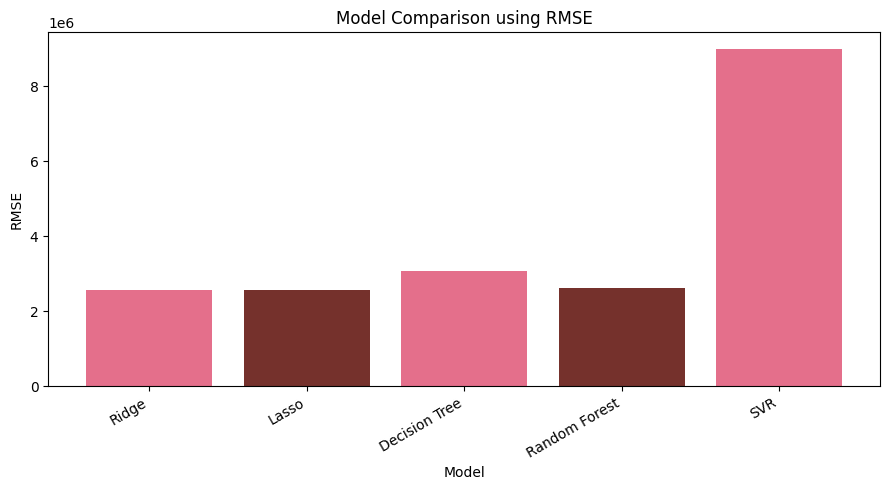

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

# Cycle your 2 colors for all models
colors = ["#E46F8B", "#75312C"] * 5

plt.bar(
    results_df["Model"],
    results_df["RMSE"],
    color=colors[:len(results_df)]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison using RMSE")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### 💡 Insights: Model Group Comparison
- **Regularized linear models:** best overall, accurate, simple and fast, and easy to interpret through coefficients.
- **Tree-based models:** Random Forest is competitive, while the single tree is weaker. They offer a good option if non-linear patterns exist.
- **SVR:** worst here, mainly due to scale and tuning issues rather than the algorithm itself.
- **Recommendation:** Lasso or Ridge for the final model, with Random Forest as a strong backup.

### 24. Identify signs of overfitting or underfitting in each model.

In [36]:
overfitting_results = []

# Ridge
ridge_train_r2 = r2_score(y_train, best_ridge.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge_pred)

# Lasso
lasso_train_r2 = r2_score(y_train, best_lasso.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, best_lasso.predict(X_test_scaled))

# Decision Tree
tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

# Random Forest
forest_train_r2 = r2_score(y_train, forest_train_pred)
forest_test_r2 = r2_score(y_test, forest_test_pred)

# SVR
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)

model_r2 = {
    "Ridge": (ridge_train_r2, ridge_test_r2),
    "Lasso": (lasso_train_r2, lasso_test_r2),
    "Decision Tree": (tree_train_r2, tree_test_r2),
    "Random Forest": (forest_train_r2, forest_test_r2),
    "SVR": (svr_train_r2, svr_test_r2)
}

for model, (train_r2, test_r2) in model_r2.items():

    difference = train_r2 - test_r2

    if difference > 0.10:
        result = "Overfitting"
    elif train_r2 < 0.60 and test_r2 < 0.60:
        result = "Underfitting"
    else:
        result = "Good Fit"

    overfitting_results.append([
        model,
        train_r2,
        test_r2,
        result
    ])

fit_results = pd.DataFrame(
    overfitting_results,
    columns=["Model", "Training R2", "Validation R2", "Fit"])

print(fit_results)

           Model  Training R2  Validation R2           Fit
0          Ridge     0.916185       0.918726      Good Fit
1          Lasso     0.916186       0.918742      Good Fit
2  Decision Tree     0.899431       0.883457      Good Fit
3  Random Forest     0.926211       0.914265      Good Fit
4            SVR    -0.006603      -0.002672  Underfitting


#### 💡 Insights: Overfitting / Underfitting
- **Ridge, Lasso, Random Forest, Decision Tree (pruned):** train and validation R² are within about 0.01 to 0.02 of each other, so all are a **good fit**.
- Ridge and Lasso even score slightly higher on validation than on training, a sign of a very stable model.
- **SVR** has R² ≈ 0 on both sets, a clear case of **underfitting**.
- The unpruned tree (Q15) was the only overfit model, and pruning fixed it.